# VOC Main Notebook

This notebook is the shared starting point for the group project.

## Contents
1. Setup and dataset path checks.
2. Shared split loading and annotation parsing.
3. Split integrity checks.
4. EDA for class balance and bounding box quality.
5. Model-ready tables and PyTorch Dataset/DataLoader scaffolding.

Each team member should keep the split logic unchanged and only swap in their own model code.

In [26]:
from pathlib import Path
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, ImageDraw
import torch
from torch.utils.data import DataLoader, Dataset

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

In [27]:
PROJECT_ROOT = Path.cwd()
TRAINVAL_ROOT = PROJECT_ROOT / "trainval" / "VOC2012"
TEST_ROOT = PROJECT_ROOT / "test" / "VOC2012"

for path in [TRAINVAL_ROOT, TEST_ROOT]:
    if not path.exists():
        raise FileNotFoundError(f"Missing expected VOC folder: {path}")

VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor",
]
CLASS_TO_ID = {name: idx for idx, name in enumerate(VOC_CLASSES)}
ID_TO_CLASS = {idx: name for name, idx in CLASS_TO_ID.items()}

print("Project root:", PROJECT_ROOT)
print("Train/Val root:", TRAINVAL_ROOT)
print("Test root:", TEST_ROOT)

Project root: /Users/michaelkaramichalis/Library/Mobile Documents/com~apple~CloudDocs/MSc Advanced Computer Science/CMT316 - Applications of Machine Learning/Assessment 2/VOC_SPLIT_EDA
Train/Val root: /Users/michaelkaramichalis/Library/Mobile Documents/com~apple~CloudDocs/MSc Advanced Computer Science/CMT316 - Applications of Machine Learning/Assessment 2/VOC_SPLIT_EDA/trainval/VOC2012
Test root: /Users/michaelkaramichalis/Library/Mobile Documents/com~apple~CloudDocs/MSc Advanced Computer Science/CMT316 - Applications of Machine Learning/Assessment 2/VOC_SPLIT_EDA/test/VOC2012


In [28]:
def load_split_ids(root: Path, split_name: str) -> list[str]:
    split_file = root / "ImageSets" / "Main" / f"{split_name}.txt"
    if not split_file.exists():
        return []
    return [line.strip() for line in split_file.read_text().splitlines() if line.strip()]


def parse_annotation(xml_path: Path, image_id: str, split_name: str) -> tuple[dict, list[dict]]:
    root = ET.parse(xml_path).getroot()

    size_node = root.find("size")
    width = int(size_node.findtext("width", default="0")) if size_node is not None else 0
    height = int(size_node.findtext("height", default="0")) if size_node is not None else 0

    objects = []
    for obj in root.findall("object"):
        cls = obj.findtext("name", default="").strip()
        if cls not in CLASS_TO_ID:
            continue

        box = obj.find("bndbox")
        if box is None:
            continue

        xmin = int(float(box.findtext("xmin", default="0")))
        ymin = int(float(box.findtext("ymin", default="0")))
        xmax = int(float(box.findtext("xmax", default="0")))
        ymax = int(float(box.findtext("ymax", default="0")))

        objects.append({
            "image_id": image_id,
            "split": split_name,
            "cls": cls,
            "class_id": CLASS_TO_ID[cls],
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax,
            "bbox_xywh": [xmin, ymin, xmax - xmin + 1, ymax - ymin + 1],
            "area": max(1, xmax - xmin + 1) * max(1, ymax - ymin + 1),
            "difficult": int(obj.findtext("difficult", default="0")),
            "truncated": int(obj.findtext("truncated", default="0")),
            "occluded": int(obj.findtext("occluded", default="0")),
            "width": width,
            "height": height,
        })

    image_meta = {"image_id": image_id, "split": split_name, "width": width, "height": height}
    return image_meta, objects


def build_split_tables(root: Path, split_name: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    image_rows, object_rows = [], []
    ann_dir = root / "Annotations"

    for image_id in load_split_ids(root, split_name):
        xml_path = ann_dir / f"{image_id}.xml"
        if not xml_path.exists():
            image_rows.append({"image_id": image_id, "split": split_name, "width": np.nan, "height": np.nan})
            continue

        image_meta, objects = parse_annotation(xml_path, image_id, split_name)
        image_rows.append(image_meta)
        object_rows.extend(objects)

    images_df = pd.DataFrame(image_rows).drop_duplicates(subset=["image_id", "split"])
    objects_df = pd.DataFrame(object_rows)

    if not objects_df.empty:
        objects_df["box_w"] = (objects_df["xmax"] - objects_df["xmin"] + 1).clip(lower=1)
        objects_df["box_h"] = (objects_df["ymax"] - objects_df["ymin"] + 1).clip(lower=1)
        objects_df["box_area"] = objects_df["box_w"] * objects_df["box_h"]
        objects_df["aspect_ratio"] = objects_df["box_w"] / objects_df["box_h"]
        image_area = (objects_df["width"] * objects_df["height"]).replace(0, np.nan)
        objects_df["norm_area"] = objects_df["box_area"] / image_area

    return images_df, objects_df

In [29]:
train_images, train_objects = build_split_tables(TRAINVAL_ROOT, "train")
val_images, val_objects = build_split_tables(TRAINVAL_ROOT, "val")
test_images, test_objects = build_split_tables(TEST_ROOT, "test")

images_df = pd.concat([train_images, val_images, test_images], ignore_index=True)
objects_df = pd.concat([train_objects, val_objects, test_objects], ignore_index=True)

train_ids = set(train_images["image_id"].dropna())
val_ids = set(val_images["image_id"].dropna())
test_ids = set(test_images["image_id"].dropna())

print("Split sizes:")
print("train:", len(train_ids))
print("val:", len(val_ids))
print("test:", len(test_ids))
print("train-val overlap:", len(train_ids & val_ids))
print("train-test overlap:", len(train_ids & test_ids))
print("val-test overlap:", len(val_ids & test_ids))

print("\nImage table preview:")
display(images_df.head())
print("\nObject table preview:")
display(objects_df.head())

Split sizes:
train: 5717
val: 5823
test: 10991
train-val overlap: 0
train-test overlap: 0
val-test overlap: 0

Image table preview:


,image_id,split,width,height
0,2008_000008,train,500.0,442.0
1,2008_000015,train,500.0,327.0
2,2008_000019,train,480.0,272.0
3,2008_000023,train,333.0,500.0
4,2008_000028,train,500.0,375.0



Object table preview:


,image_id,split,cls,class_id,xmin,ymin,xmax,ymax,bbox_xywh,area,difficult,truncated,occluded,width,height,box_w,box_h,box_area,aspect_ratio,norm_area
0,2008_000008,train,horse,12,53,87,471,420,"[53, 87, 419, 334]",139946,0,0,1,500,442,419,334,139946,1.254491,0.633240
1,2008_000008,train,person,14,158,44,289,167,"[158, 44, 132, 124]",16368,0,1,0,500,442,132,124,16368,1.064516,0.074063
2,2008_000015,train,bottle,4,270,1,378,176,"[270, 1, 109, 176]",19184,0,1,1,500,327,109,176,19184,0.619318,0.117333
3,2008_000015,train,bottle,4,57,1,164,150,"[57, 1, 108, 150]",16200,0,1,1,500,327,108,150,16200,0.720000,0.099083
4,2008_000019,train,dog,11,139,2,372,197,"[139, 2, 234, 196]",45864,0,0,0,480,272,234,196,45864,1.193878,0.351287


## 4. EDA: Class Balance and Box Quality

This section gives quick diagnostics that every team member should see before training: class imbalance, annotation flags, and bounding-box geometry.

In [30]:
trainval_images = pd.concat([train_images, val_images], ignore_index=True).drop_duplicates(subset=["image_id"])
trainval_objects = pd.concat([train_objects, val_objects], ignore_index=True)

if trainval_objects.empty:
    raise RuntimeError("No train/val annotations found. Check annotation paths and split files.")

eda_df = trainval_objects.copy()
obj_counts = eda_df.groupby("cls").size().reindex(VOC_CLASSES, fill_value=0).rename("object_count")
img_counts = eda_df.groupby("cls")["image_id"].nunique().reindex(VOC_CLASSES, fill_value=0).rename("image_count")
class_stats = pd.concat([img_counts, obj_counts], axis=1).sort_values("object_count", ascending=False)

class_stats

,image_count,object_count
cls,,
person,4374,10129
chair,1298,2906
car,1229,2364
dog,1297,1541
bottle,768,1482
cat,1084,1227
bird,773,1221
pottedplant,568,1099
boat,516,999


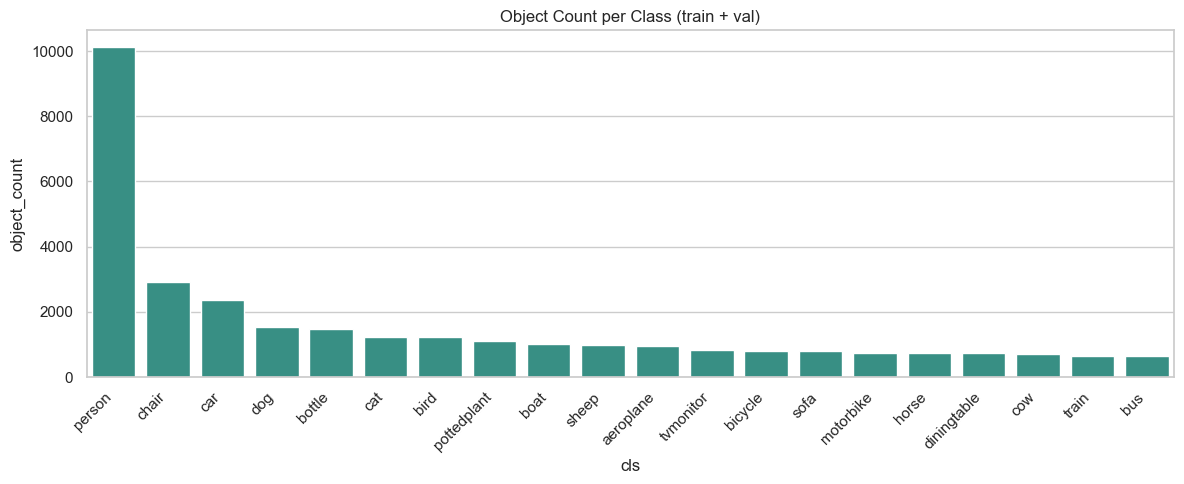

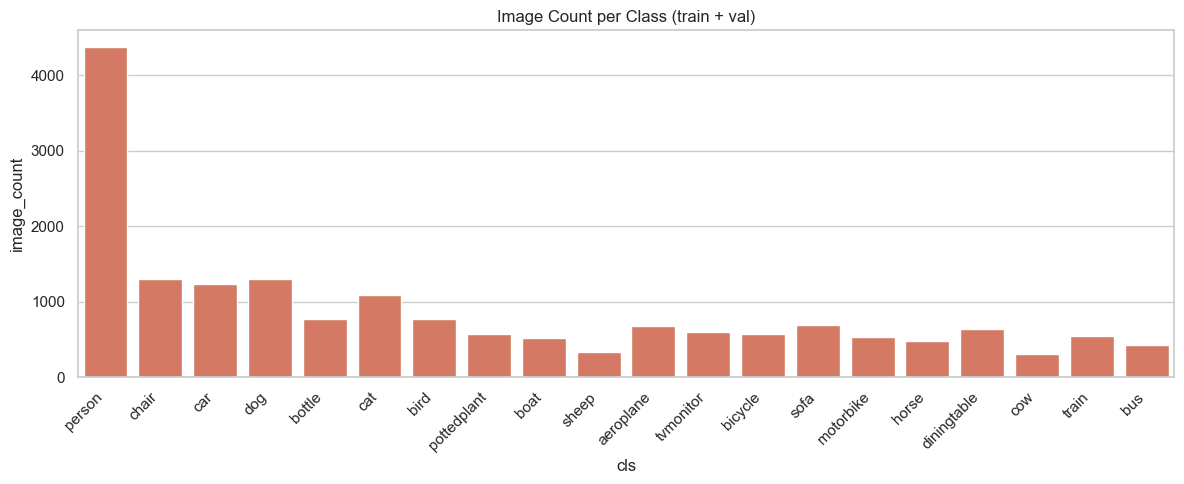

In [31]:
plt.figure(figsize=(12, 5))
order = class_stats.index.tolist()
sns.barplot(data=class_stats.reset_index(), x="cls", y="object_count", order=order, color="#2a9d8f")
plt.xticks(rotation=45, ha="right")
plt.title("Object Count per Class (train + val)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=class_stats.reset_index(), x="cls", y="image_count", order=order, color="#e76f51")
plt.xticks(rotation=45, ha="right")
plt.title("Image Count per Class (train + val)")
plt.tight_layout()
plt.show()

,difficult_rate,truncated_rate,occluded_rate
0,0.130256,0.519312,0.417065


,box_w,box_h,box_area,aspect_ratio,norm_area
count,31561.00000,31561.000000,31561.000000,31561.000000,31561.000000
mean,161.20839,163.269098,36735.133266,1.103780,0.204527
std,136.13578,115.397714,45406.548028,0.838940,0.249498
min,3.00000,5.000000,24.000000,0.074324,0.000139
10%,25.00000,33.000000,960.000000,0.381743,0.005440
25%,52.00000,64.000000,3430.000000,0.567901,0.019219
50%,115.00000,139.000000,16328.000000,0.881944,0.091392
75%,241.00000,244.000000,54569.000000,1.376923,0.305280
90%,382.00000,332.000000,108267.000000,2.037736,0.606396
max,500.00000,500.000000,250000.000000,19.840000,1.000000


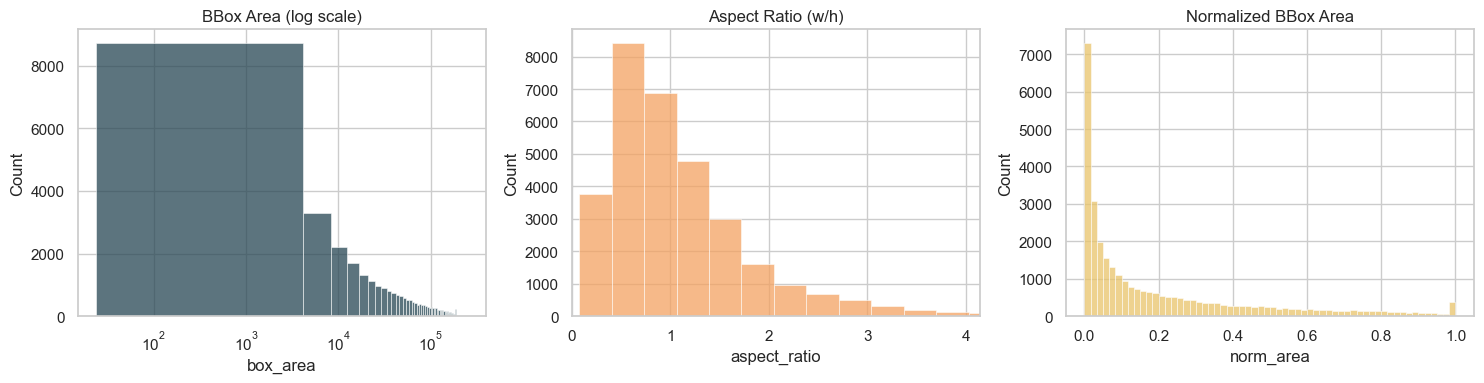

In [32]:
flag_summary = pd.DataFrame({
    "difficult_rate": [eda_df["difficult"].mean()],
    "truncated_rate": [eda_df["truncated"].mean()],
    "occluded_rate": [eda_df["occluded"].mean()],
})

geom_stats = eda_df[["box_w", "box_h", "box_area", "aspect_ratio", "norm_area"]].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]
)

display(flag_summary)
display(geom_stats)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(eda_df["box_area"], bins=60, ax=axes[0], color="#264653")
axes[0].set_xscale("log")
axes[0].set_title("BBox Area (log scale)")

sns.histplot(eda_df["aspect_ratio"], bins=60, ax=axes[1], color="#f4a261")
axes[1].set_xlim(0, min(10, np.nanpercentile(eda_df["aspect_ratio"], 99)))
axes[1].set_title("Aspect Ratio (w/h)")

sns.histplot(eda_df["norm_area"].dropna(), bins=60, ax=axes[2], color="#e9c46a")
axes[2].set_title("Normalized BBox Area")

plt.tight_layout()
plt.show()

## 5. Model-ready tables

These filtered tables are the default recommendation for training and validation (difficult objects removed).

In [33]:
train_model_df = train_objects.copy()
train_model_df = train_model_df[
    (train_model_df["xmax"] >= train_model_df["xmin"]) &
    (train_model_df["ymax"] >= train_model_df["ymin"])
].reset_index(drop=True)
train_model_df_ignoring_difficult = train_model_df[train_model_df["difficult"] == 0].copy()

val_model_df = val_objects.copy()
val_model_df = val_model_df[
    (val_model_df["xmax"] >= val_model_df["xmin"]) &
    (val_model_df["ymax"] >= val_model_df["ymin"])
].reset_index(drop=True)
val_model_df_ignoring_difficult = val_model_df[val_model_df["difficult"] == 0].copy()

print("Train objects:", len(train_model_df), "| train without difficult:", len(train_model_df_ignoring_difficult))
print("Val objects:", len(val_model_df), "| val without difficult:", len(val_model_df_ignoring_difficult))

display(train_model_df_ignoring_difficult.head())

Train objects: 15774 | train without difficult: 13609
Val objects: 15787 | val without difficult: 13841


,image_id,split,cls,class_id,xmin,ymin,xmax,ymax,bbox_xywh,area,difficult,truncated,occluded,width,height,box_w,box_h,box_area,aspect_ratio,norm_area
0,2008_000008,train,horse,12,53,87,471,420,"[53, 87, 419, 334]",139946,0,0,1,500,442,419,334,139946,1.254491,0.633240
1,2008_000008,train,person,14,158,44,289,167,"[158, 44, 132, 124]",16368,0,1,0,500,442,132,124,16368,1.064516,0.074063
2,2008_000015,train,bottle,4,270,1,378,176,"[270, 1, 109, 176]",19184,0,1,1,500,327,109,176,19184,0.619318,0.117333
3,2008_000015,train,bottle,4,57,1,164,150,"[57, 1, 108, 150]",16200,0,1,1,500,327,108,150,16200,0.720000,0.099083
4,2008_000019,train,dog,11,139,2,372,197,"[139, 2, 234, 196]",45864,0,0,0,480,272,234,196,45864,1.193878,0.351287


## 6. Dataset and Dataloader

The dataset returns PIL images and a target dictionary with VOC-style bounding boxes. The standard PyTorch `DataLoader` handles batching, and the `collate_fn` keeps variable numbers of boxes per image intact.

In [34]:
class VOCLocalisationDataset(Dataset):
    def __init__(self, root: Path, image_ids: list[str], objects_df: pd.DataFrame):
        self.root = root
        self.image_ids = list(image_ids)
        self.objects_by_image = {}

        if not objects_df.empty:
            for image_id, group in objects_df.groupby("image_id"):
                records = []
                for row in group.itertuples(index=False):
                    records.append({
                        "bbox": [float(row.xmin), float(row.ymin), float(row.xmax - row.xmin + 1), float(row.ymax - row.ymin + 1)],
                        "category_id": int(row.class_id),
                        "area": float(row.area),
                        "iscrowd": 0,
                    })
                self.objects_by_image[image_id] = records

    def __len__(self) -> int:
        return len(self.image_ids)

    def __getitem__(self, idx: int):
        image_id = self.image_ids[idx]
        image_path = self.root / "JPEGImages" / f"{image_id}.jpg"
        image = Image.open(image_path).convert("RGB")
        annotations = self.objects_by_image.get(image_id, [])
        target = {"image_id": image_id, "annotations": annotations}
        return image, target


def collate_fn(batch):
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    return images, targets


train_ds = VOCLocalisationDataset(TRAINVAL_ROOT, list(train_ids), train_model_df_ignoring_difficult)
val_ds = VOCLocalisationDataset(TRAINVAL_ROOT, list(val_ids), val_model_df_ignoring_difficult)
test_ds = VOCLocalisationDataset(TEST_ROOT, list(test_ids), test_objects)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=2, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=2, shuffle=False, collate_fn=collate_fn)

len(train_ds), len(val_ds), len(test_ds)

(5717, 5823, 10991)

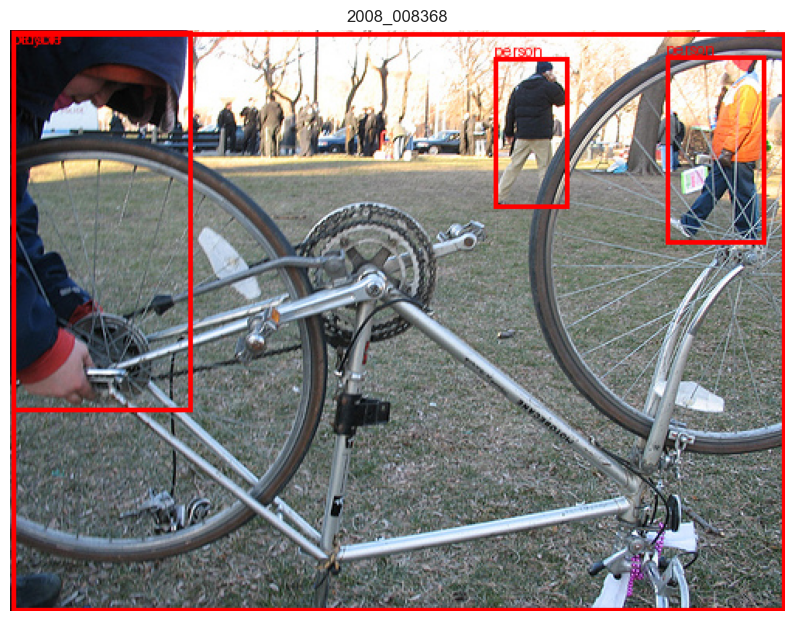

In [35]:
def plot_sample(image_id: str, root: Path, objects_df: pd.DataFrame) -> None:
    image_path = root / "JPEGImages" / f"{image_id}.jpg"
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    sample_rows = objects_df[objects_df["image_id"] == image_id]
    for row in sample_rows.itertuples(index=False):
        left = float(row.xmin)
        top = float(row.ymin)
        right = float(row.xmax)
        bottom = float(row.ymax)
        draw.rectangle([left, top, right, bottom], outline="red", width=3)
        draw.text((left, max(0, top - 10)), row.cls, fill="red")

    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title(image_id)
    plt.show()


sample_image_id = next(iter(train_ids)) if train_ids else None
if sample_image_id is not None:
    plot_sample(sample_image_id, TRAINVAL_ROOT, train_model_df_ignoring_difficult)

In [36]:
batch_images, batch_targets = next(iter(train_loader))
print("Batch size:", len(batch_images))
print("First image type:", type(batch_images[0]))
print("First target keys:", batch_targets[0].keys())
print("First target annotations count:", len(batch_targets[0]["annotations"]))

Batch size: 2
First image type: <class 'PIL.Image.Image'>
First target keys: dict_keys(['image_id', 'annotations'])
First target annotations count: 1


## 7. How to use this notebook

- Everyone should use the same `train.txt`, `val.txt`, and `test.txt` files.
- Use `train_model_df_ignoring_difficult` and `val_model_df_ignoring_difficult` for training/validation annotations.
- Use `test_objects` and `test_ds` for test-time predictions.
- Keep split logic and preprocessing unchanged so the final ensemble is leakage-free.